In [1]:
import random
from play_4x4_world_game.environment import GridWorld4x4

""" Checking MDP process """
env = GridWorld4x4()

state = random.choice(env.states)
total_rewards = 0
t = 0
while True:
    action = random.choice(env.actions)
    next_state, reward, terminated = env.step(state, action)
    print(
        f"S_{t}({state}), A_{t}({action.name}) -> R_{t+1}({reward}), S_{t+1}({next_state}), {terminated}"
    )
    state = next_state
    total_rewards += reward
    t += 1
    if terminated:
        break

total_rewards
# 

S_0(0), A_0(RIGHT) -> R_1(0.0), S_1(0), True


0.0

In [2]:
# evaluate_policy
from play_4x4_world_game.policy import EquiprobableRandomPolicy
from play_4x4_world_game.policy_evaluation import iterative_policy_evaluation

env2 = GridWorld4x4()
policy = EquiprobableRandomPolicy(env2)

# evaluate policy
vpi_values = iterative_policy_evaluation(env, policy)
vpi_values

{0: 0.0,
 1: -13.999989815018463,
 2: -19.99998490769143,
 3: -21.99998311081417,
 4: -13.999989815018463,
 5: -17.99998670456869,
 6: -19.99998500864881,
 7: -19.99998490769143,
 8: -19.99998490769143,
 9: -19.99998500864881,
 10: -17.99998670456869,
 11: -13.999989815018465,
 12: -21.99998311081417,
 13: -19.99998490769143,
 14: -13.999989815018463,
 15: 0.0}

In [3]:
# improve the prolicy
from play_4x4_world_game.policy_improvement import gready_actions
from collections import defaultdict

state_best_actions = defaultdict(tuple)

for state in env2.states:
    best_action = gready_actions(
        env=env2, vpi_values=vpi_values, state=state, gamma=1.0
    )
    state_best_actions[state] = best_action
state_best_actions

defaultdict(tuple,
            {0: (),
             1: (<Action.LEFT: (-1, 0)>,),
             2: (<Action.LEFT: (-1, 0)>,),
             3: (<Action.DOWN: (0, 1)>, <Action.LEFT: (-1, 0)>),
             4: (<Action.UP: (0, -1)>,),
             5: (<Action.UP: (0, -1)>, <Action.LEFT: (-1, 0)>),
             6: (<Action.DOWN: (0, 1)>, <Action.LEFT: (-1, 0)>),
             7: (<Action.DOWN: (0, 1)>,),
             8: (<Action.UP: (0, -1)>,),
             9: (<Action.UP: (0, -1)>, <Action.RIGHT: (1, 0)>),
             10: (<Action.DOWN: (0, 1)>, <Action.RIGHT: (1, 0)>),
             11: (<Action.DOWN: (0, 1)>,),
             12: (<Action.UP: (0, -1)>, <Action.RIGHT: (1, 0)>),
             13: (<Action.RIGHT: (1, 0)>,),
             14: (<Action.RIGHT: (1, 0)>,),
             15: ()})

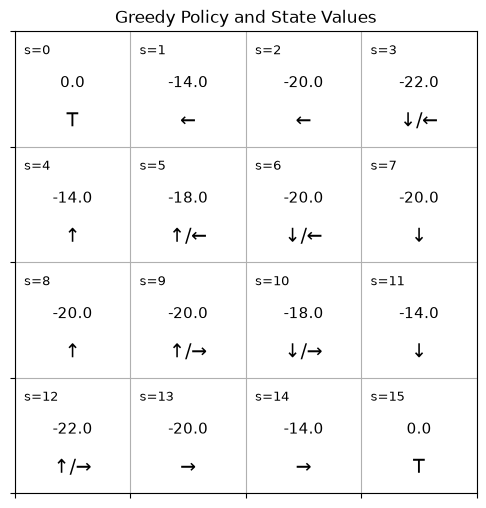

In [4]:
from play_4x4_world_game.view.view_policy import plot_improved_policy
""" See the plot of best actions from each state with their respective state value """
plot_improved_policy(values=vpi_values, best_actions=state_best_actions)

In [5]:
# improve policy
from play_4x4_world_game.policy_improvement import improve_greedy_policy
greedy_policy = improve_greedy_policy(env2, vpi_values)
greedy_policy

GreedyPolicy : action_map={0: (), 1: (<Action.LEFT: (-1, 0)>,), 2: (<Action.LEFT: (-1, 0)>,), 3: (<Action.DOWN: (0, 1)>, <Action.LEFT: (-1, 0)>), 4: (<Action.UP: (0, -1)>,), 5: (<Action.UP: (0, -1)>, <Action.LEFT: (-1, 0)>), 6: (<Action.DOWN: (0, 1)>, <Action.LEFT: (-1, 0)>), 7: (<Action.DOWN: (0, 1)>,), 8: (<Action.UP: (0, -1)>,), 9: (<Action.UP: (0, -1)>, <Action.RIGHT: (1, 0)>), 10: (<Action.DOWN: (0, 1)>, <Action.RIGHT: (1, 0)>), 11: (<Action.DOWN: (0, 1)>,), 12: (<Action.UP: (0, -1)>, <Action.RIGHT: (1, 0)>), 13: (<Action.RIGHT: (1, 0)>,), 14: (<Action.RIGHT: (1, 0)>,), 15: ()}

In [6]:
# see the state -> actions probabilities

from play_4x4_world_game.environment import Action

state_action_map = defaultdict(dict)
for state in env2.states:
    for action in env2.actions:
        state_action_map[state][action.name] = greedy_policy.probability(state, action)

state_action_map

defaultdict(dict,
            {0: {'UP': 0.0, 'DOWN': 0.0, 'LEFT': 0.0, 'RIGHT': 0.0},
             1: {'UP': 0.0, 'DOWN': 0.0, 'LEFT': 1.0, 'RIGHT': 0.0},
             2: {'UP': 0.0, 'DOWN': 0.0, 'LEFT': 1.0, 'RIGHT': 0.0},
             3: {'UP': 0.0, 'DOWN': 0.5, 'LEFT': 0.5, 'RIGHT': 0.0},
             4: {'UP': 1.0, 'DOWN': 0.0, 'LEFT': 0.0, 'RIGHT': 0.0},
             5: {'UP': 0.5, 'DOWN': 0.0, 'LEFT': 0.5, 'RIGHT': 0.0},
             6: {'UP': 0.0, 'DOWN': 0.5, 'LEFT': 0.5, 'RIGHT': 0.0},
             7: {'UP': 0.0, 'DOWN': 1.0, 'LEFT': 0.0, 'RIGHT': 0.0},
             8: {'UP': 1.0, 'DOWN': 0.0, 'LEFT': 0.0, 'RIGHT': 0.0},
             9: {'UP': 0.5, 'DOWN': 0.0, 'LEFT': 0.0, 'RIGHT': 0.5},
             10: {'UP': 0.0, 'DOWN': 0.5, 'LEFT': 0.0, 'RIGHT': 0.5},
             11: {'UP': 0.0, 'DOWN': 1.0, 'LEFT': 0.0, 'RIGHT': 0.0},
             12: {'UP': 0.5, 'DOWN': 0.0, 'LEFT': 0.0, 'RIGHT': 0.5},
             13: {'UP': 0.0, 'DOWN': 0.0, 'LEFT': 0.0, 'RIGHT': 1.0},
            

In [10]:
# policy iteration
from play_4x4_world_game.policy_iteration import policy_iteration

env3 = GridWorld4x4()
greedy_policy, vpi_values_2, iteration = policy_iteration(env3)

greedy_policy.action_map, vpi_values_2, iteration

({0: (),
  1: (<Action.LEFT: (-1, 0)>,),
  2: (<Action.LEFT: (-1, 0)>,),
  3: (<Action.DOWN: (0, 1)>, <Action.LEFT: (-1, 0)>),
  4: (<Action.UP: (0, -1)>,),
  5: (<Action.UP: (0, -1)>, <Action.LEFT: (-1, 0)>),
  6: (<Action.UP: (0, -1)>,
   <Action.DOWN: (0, 1)>,
   <Action.LEFT: (-1, 0)>,
   <Action.RIGHT: (1, 0)>),
  7: (<Action.DOWN: (0, 1)>,),
  8: (<Action.UP: (0, -1)>,),
  9: (<Action.UP: (0, -1)>,
   <Action.DOWN: (0, 1)>,
   <Action.LEFT: (-1, 0)>,
   <Action.RIGHT: (1, 0)>),
  10: (<Action.DOWN: (0, 1)>, <Action.RIGHT: (1, 0)>),
  11: (<Action.DOWN: (0, 1)>,),
  12: (<Action.UP: (0, -1)>, <Action.RIGHT: (1, 0)>),
  13: (<Action.RIGHT: (1, 0)>,),
  14: (<Action.RIGHT: (1, 0)>,),
  15: ()},
 {0: 0.0,
  1: -1.0,
  2: -2.0,
  3: -3.0,
  4: -1.0,
  5: -2.0,
  6: -3.0,
  7: -2.0,
  8: -2.0,
  9: -3.0,
  10: -2.0,
  11: -1.0,
  12: -3.0,
  13: -2.0,
  14: -1.0,
  15: 0.0},
 3)

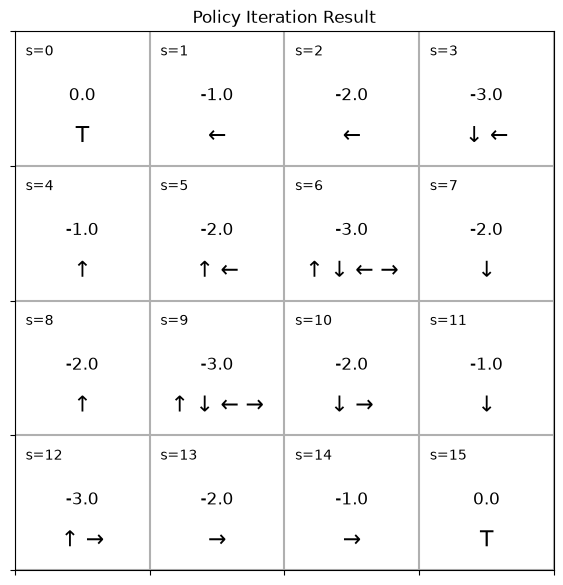

In [11]:
from play_4x4_world_game.view.view_policy import plot_iterated_policy

plot_iterated_policy(greedy_policy.action_map, vpi_values_2)